1D CV test


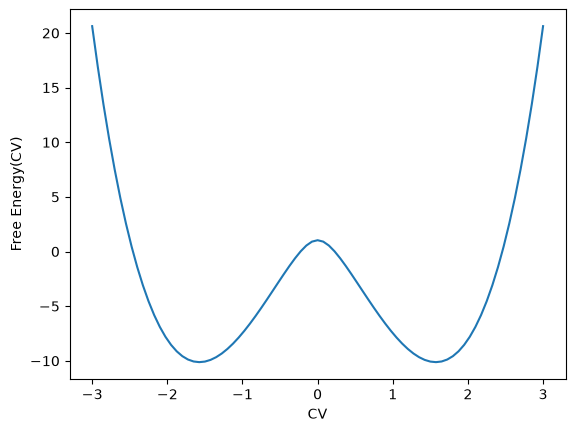

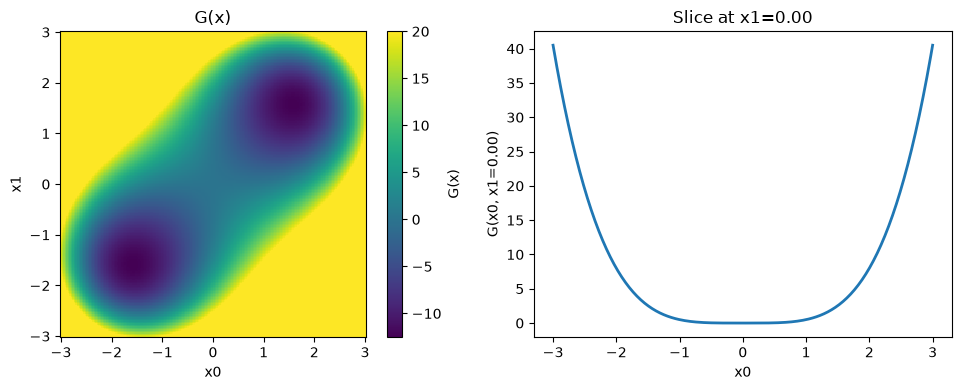

trajectories shape (4, 3000, 2)
potentials shape (4, 300, 81)
sample final coords [[ 0.02023618  1.2527791 ]
 [-2.2894604  -1.41980333]
 [-1.62176374 -1.5063326 ]
 [-1.82255749 -1.46738543]]
True True
(2,)


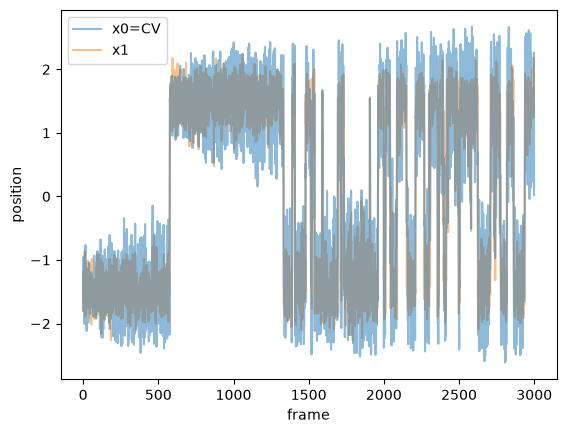

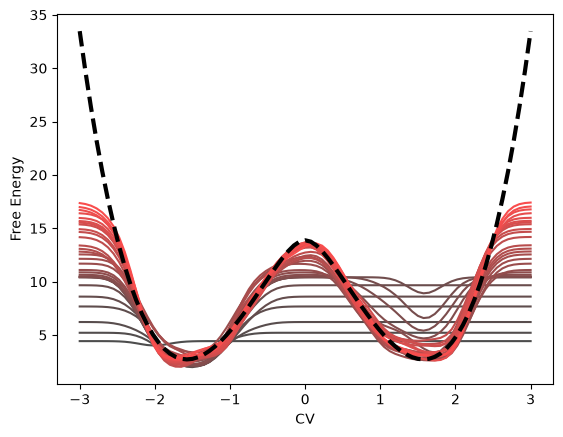

(2,)


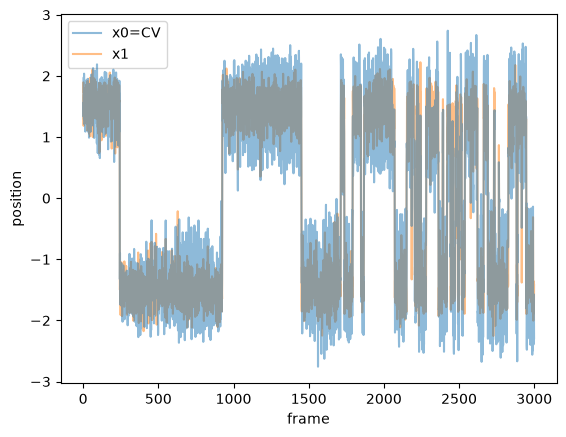

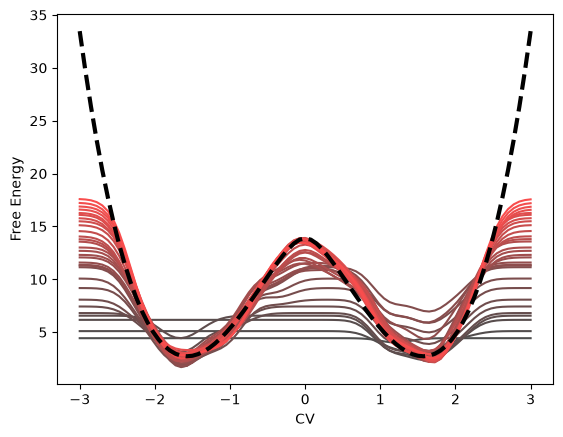

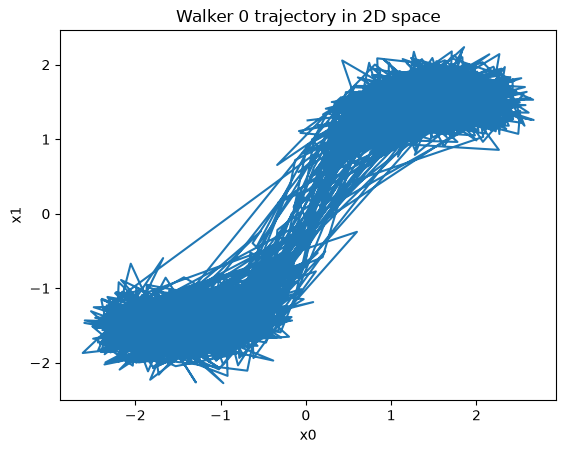

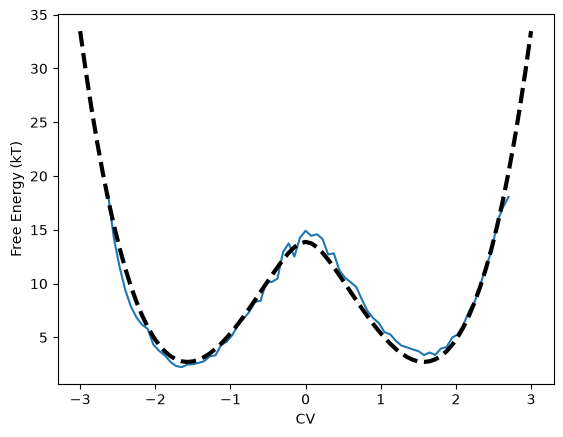

2D CV test
2cv trajectories shape (4, 3000, 2)
2cv potentials shape (4, 300, 25, 25)
True True


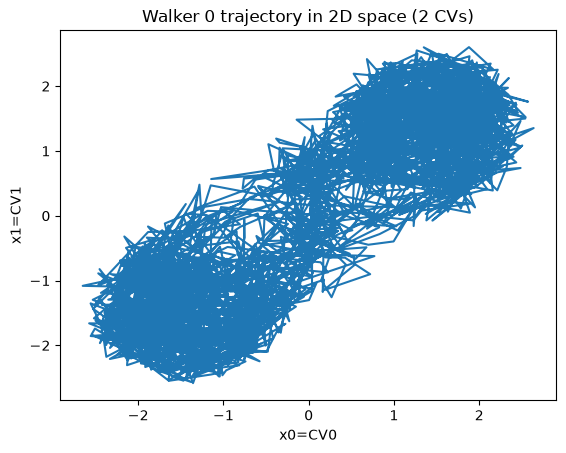

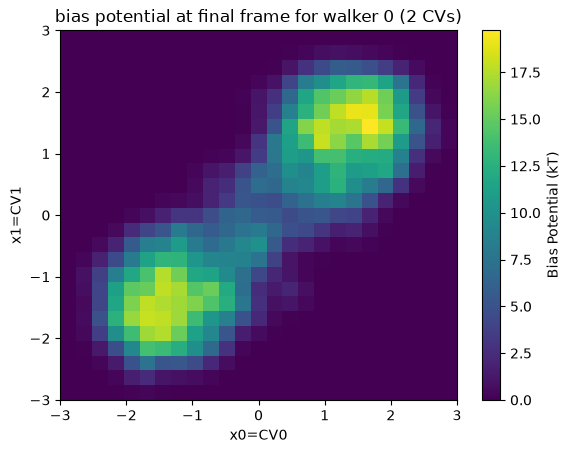

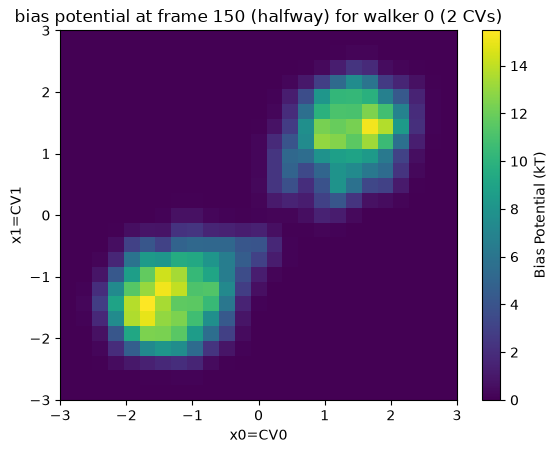

note that different-dimensional CVs may require different omega values to be effective, (copilot: 'and the bias potential may not be as smooth in higher dimensions due to fewer samples per grid point').


In [13]:
import test_propagators_grid
import importlib
importlib.reload(test_propagators_grid)
#test_propagators_grid.test_free_energy_on_cv_grid()
print("1D CV test")
test_propagators_grid.test_propagators_grid_1d_cv()
print("2D CV test")
test_propagators_grid.test_propagators_grid_2d_cv()


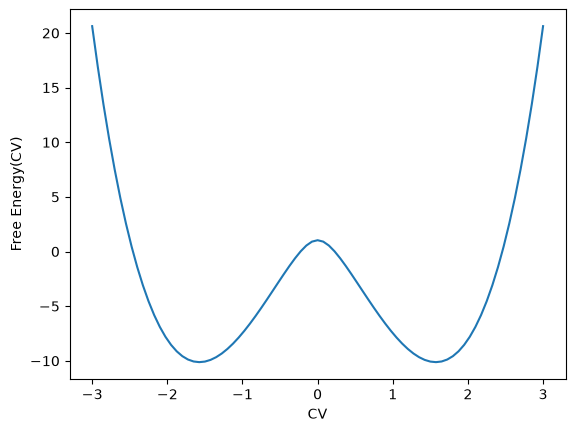

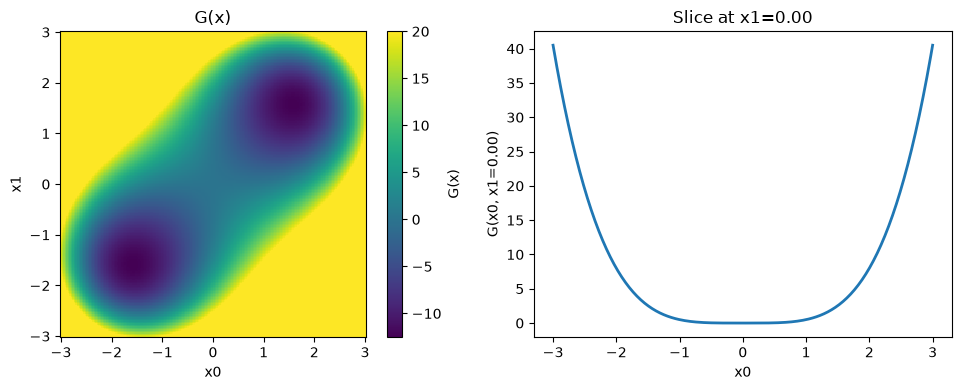

trajectories shape (4, 3000, 2)
potentials shape (4, 300, 81)
sample final coords [[-2.27626419 -1.72231144]
 [ 0.35614002 -0.58809531]
 [-0.39394504 -0.74223072]
 [-0.05974422 -1.07122054]]
True True
(2,)


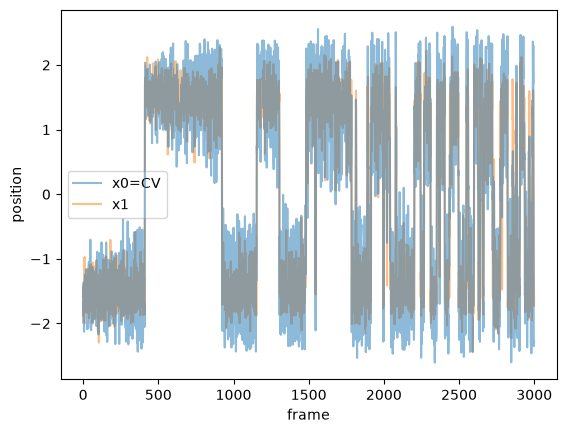

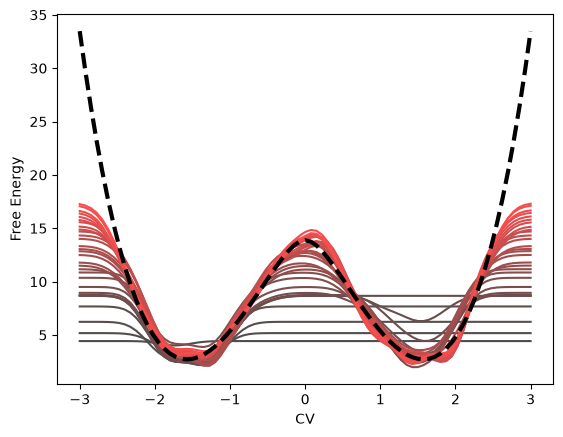

(2,)


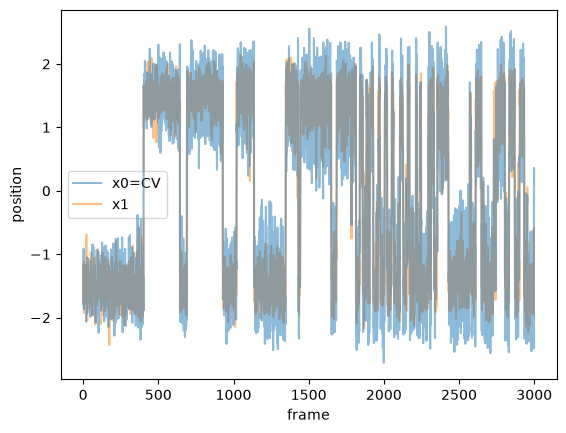

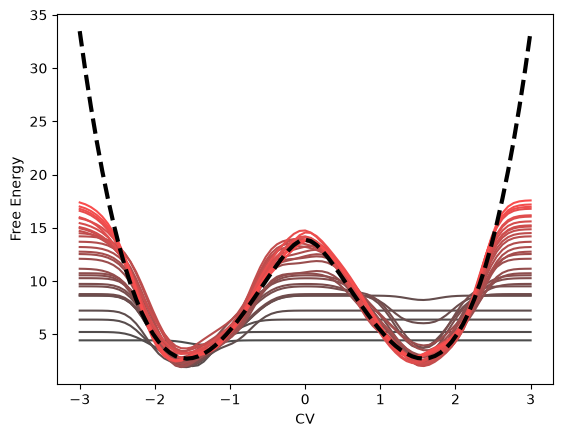

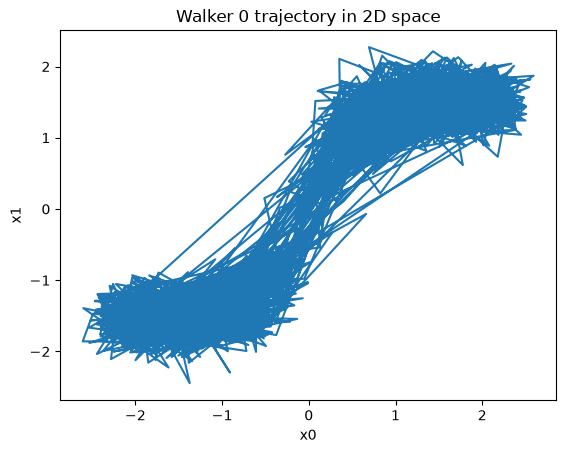

3426.997735666504 3426.997735666504


/var/folders/xr/fxj70vfj0bv2kxlwy2bbtz880000gn/T/ipykernel_14842/3464000926.py:96: RuntimeWarning: divide by zero encountered in log
  plt.plot(cv_grid, -kT*np.log(pops_1d[0]/np.sum(pops_1d[0])))


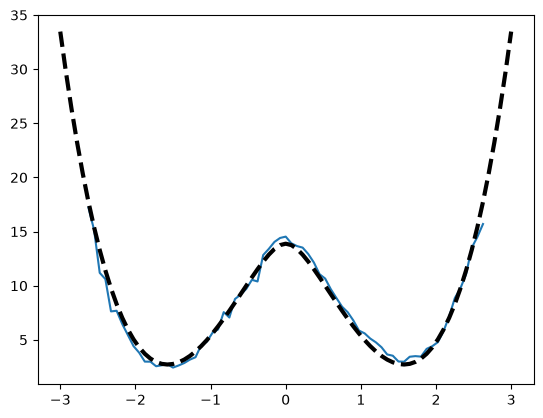

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import collective_variables
import energy_landscapes
from propagators_grid import propagate
import visualization
import collective_variable_analysis



#def test_propagators_grid_1d_cv():

n_walkers = 4

T=1
kB=1
kT = kB*T

sim_system = energy_landscapes.diagonal_2well_2d_system

CV = collective_variables.cv_coord0_2d_coord_1d_cv

cv_grid, free_energy_grid = collective_variable_analysis.free_energy_on_cv_grid(
        free_energy_fn=sim_system.G,
        coord_min=sim_system.coord_min,
        coord_max=sim_system.coord_max,
        n_micro_grid=sim_system.grid_n,
        cv_fn=CV.cv_funct,
        cv_min=CV.cv_min,
        cv_max=CV.cv_max,
        n_cv_grid=CV.grid_n,
        kT = kT
    )

plt.plot(cv_grid, free_energy_grid)
plt.xlabel('CV')
plt.ylabel('Free Energy(CV)')

init_coords = np.random.uniform(-1.5, 1.5, size=(n_walkers, sim_system.n_dim))
init_potentials = np.zeros((n_walkers, CV.grid_n))

sigma = np.array([0.2])
delta_T = 40
omega = 0.4

visualization.plot_G_surface(sim_system.G, x_limits = ((sim_system.coord_min[0], sim_system.coord_max[0]), (sim_system.coord_min[1], sim_system.coord_max[1])), n=200, center=None, slice_axis=0)

traj, pots, weights = propagate(
    G=sim_system.G, kB=kB, T=T, dt=0.01, xi = sim_system.xi, init_coords=init_coords,
    init_potentials=init_potentials, steps_per_saved_frame=100,
    n_gaussians=300, frames_per_gaussian=10,
    CV=CV.cv_funct, grad_CV=CV.cv_grad_funct, sigma=sigma, omega=omega, delta_T=delta_T,
    cv_min=CV.cv_min, cv_max=CV.cv_max
)

print('trajectories shape', traj.shape)
print('potentials shape', pots.shape)
print('sample final coords', traj[:, -1, :])
#print('max bias height walker0 over time', pots[0, :, :].max(axis=-1))
print(np.isfinite(traj).all(), np.isfinite(pots).all())

def plot_trj(trj, pot):
    
    print(trj[0].shape)
    plt.plot(trj[:,0], zorder=100, alpha=0.5, label='x0=CV')
    plt.plot(trj[:,1], alpha=0.5, label='x1')
    plt.xlabel('frame')
    plt.ylabel("position")
    plt.legend()
    plt.show()

    for i, Vi in enumerate(pot):
        if i%10==0:
            plt.plot(cv_grid, -Vi*(delta_T+T)/delta_T + kT*np.log(np.sum(np.exp(Vi*((delta_T+T)/delta_T)/kT))), color = [0.3+0.7*(i/len(pot)), 0.3, 0.3])

    plt.plot(cv_grid, free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT))), linestyle="dashed", color="black", linewidth="3")

    plt.xlabel("CV")
    plt.ylabel('Free Energy')
    plt.show()

plot_trj(traj[0], pots[0])
plot_trj(traj[1], pots[1])

plt.plot(traj[0,:,0], traj[0,:,1])
plt.title('Walker 0 trajectory in 2D space')
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

#pops = np.histogram2d(traj[0,:,0], traj[0,:,1], bins=CV.grid_n, range=[[CV.cv_min[0], CV.cv_max[0]], [CV.cv_min[1], CV.cv_max[1]]], density=True)
pops_1d = np.histogram(traj[0,:,0], bins=CV.grid_n, range=(CV.cv_min[0], CV.cv_max[0]), weights=weights[0,:])

print(np.sum(pops_1d[0]), np.sum(weights[0,:]))

plt.plot(cv_grid, -kT*np.log(pops_1d[0]/np.sum(pops_1d[0])))
#plt.hist(-kT*np.log(traj[0,:,0]/np.sum(traj[0,:,0])), weights = weights[0,:], bins=CV.grid_n, density=True, alpha=0.5, label='x0=CV')

fe_norm = free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT)))

plt.plot(cv_grid, fe_norm, linestyle="dashed", color="black", linewidth="3")


plt.show()
